<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana_13_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Decisión con Scikit-Learn

Este notebook está diseñado para una clase de **nivel maestría** y cubre tanto la **teoría básica** de los árboles de decisión como su **implementación práctica** con Python usando `scikit-learn`.

## 📚 1. Fundamentos Teóricos

### ¿Qué es un árbol de decisión?

Un árbol de decisión es un modelo de aprendizaje supervisado que divide el espacio de características en regiones, mediante una serie de decisiones binarias, para predecir una variable objetivo.

### Ventajas
- Fácil de interpretar
- No requiere normalización
- Trabaja con variables numéricas y categóricas

### Desventajas
- Riesgo de sobreajuste
- Sensible al ruido en los datos
- Árboles inestables ante pequeñas variaciones
---

## 🔢 2. Clasificación: Dataset Breast Cancer
### Paso 1: Cargar librerías

En este paso cargamos las librerías que vamos a emplear en este ejercicio. Estas incluyen mòdulos como sklearn.tree para el árbol de decisión, sklearn.metrics para métricas de evaluación, sklearn.model_selection para la selección de modelos

```python
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
```



In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Paso 2: Cargar datos

En este paso vamos a cargar el conjunto de datos. Usaremos un hold-out para entrenar y evaluar el modelo

```python
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Paso 3: Entrenar modelo

Una vez que cargamos la librería de árboles de decisión, usamos en esta versión como medida de impureza el indice Gini y la profundidad máxima = 3

```python
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(X_train, y_train)
```


In [ ]:
### Paso 3: Entrenar modelo


clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3)

### Paso 4: Evaluar rendimiento

Recuerda que estamos usando un hold-out. Aprovecharemos para imprimir la matriz de confusión

```python
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
```

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

[[ 59   4]
 [  3 105]]


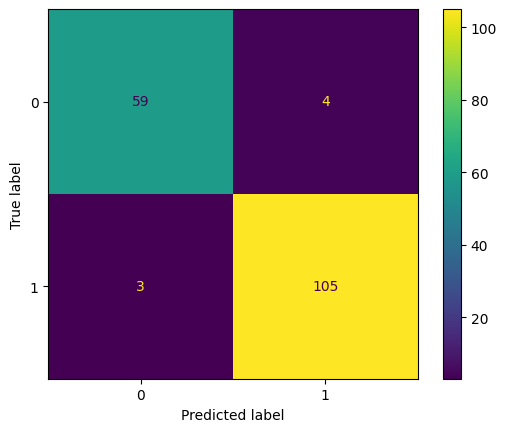

In [ ]:

### Paso 4: Evaluar rendimiento

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()
plt.show()

### Paso 5: Visualizar árbol

```python
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=load_breast_cancer().feature_names, class_names=load_breast_cancer().target_names)
plt.show()
```

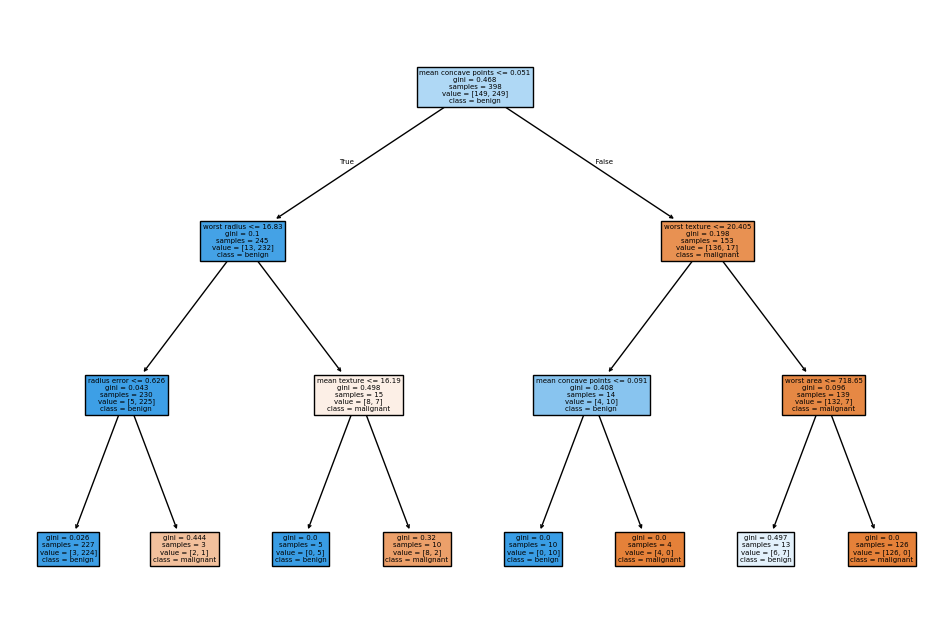

In [ ]:
### Paso 5: Visualizar árbol

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=load_breast_cancer().feature_names, class_names=load_breast_cancer().target_names)
plt.show()


### Paso 6: Exportar reglas del árbol
```python
from sklearn.tree import export_text
rules = export_text(clf, feature_names=load_breast_cancer().feature_names)
print(rules)
```

In [ ]:

from sklearn.tree import export_text
rules = export_text(clf, feature_names=load_breast_cancer().feature_names)
print(rules)


|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- radius error <= 0.63
|   |   |   |--- class: 1
|   |   |--- radius error >  0.63
|   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- mean texture <= 16.19
|   |   |   |--- class: 1
|   |   |--- mean texture >  16.19
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst texture <= 20.40
|   |   |--- mean concave points <= 0.09
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.09
|   |   |   |--- class: 0
|   |--- worst texture >  20.40
|   |   |--- worst area <= 718.65
|   |   |   |--- class: 1
|   |   |--- worst area >  718.65
|   |   |   |--- class: 0



# Ejercicios Adicionales: K-Fold Cross-Validation, Métricas, Profundidad



Ahora veremos cómo podemos construir un árbol de decisión con diferentes valores de profundidad, usando strafied k-fold cross-validation, entropy y diferentes métricas de evaluación.

## Explorar la profundidad del árbol
Objetivo: observar cómo cambia el rendimiento con distintas profundidades.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 5, 7, 10, None]
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
for d in depths:
    clf_cv = DecisionTreeClassifier(criterion='entropy',max_depth=d, random_state=42)

    results = cross_validate(clf_cv, X, y, cv=skf, scoring=scoring)
    print(f"Profundidad: {d}")
    print("Resultados:")
    for metric in scoring:
      print(f"{metric}: {results['test_' + metric].mean():.4f}")


Profundidad: 1
Resultados:
accuracy: 0.8876
precision_macro: 0.9010
recall_macro: 0.8711
f1_macro: 0.8752
Profundidad: 2
Resultados:
accuracy: 0.8859
precision_macro: 0.8914
recall_macro: 0.8738
f1_macro: 0.8756
Profundidad: 3
Resultados:
accuracy: 0.9156
precision_macro: 0.9183
recall_macro: 0.9053
f1_macro: 0.9077
Profundidad: 5
Resultados:
accuracy: 0.9385
precision_macro: 0.9369
recall_macro: 0.9330
f1_macro: 0.9338
Profundidad: 7
Resultados:
accuracy: 0.9384
precision_macro: 0.9341
recall_macro: 0.9357
f1_macro: 0.9343
Profundidad: 10
Resultados:
accuracy: 0.9384
precision_macro: 0.9341
recall_macro: 0.9357
f1_macro: 0.9343
Profundidad: None
Resultados:
accuracy: 0.9384
precision_macro: 0.9341
recall_macro: 0.9357
f1_macro: 0.9343


## Cambiar criterio de impureza (criterion)

In [ ]:
criterios = ['gini', 'entropy']
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
for crit in criterios:
  clf_cv = DecisionTreeClassifier(criterion=crit,max_depth=d, random_state=42)
  results = cross_validate(clf_cv, X, y, cv=skf, scoring=scoring)
  print(f"Criterion: {crit}")
  print("Resultados:")
  for metric in scoring:
      print(f"{metric}: {results['test_' + metric].mean():.4f}")



Criterion: gini
Resultados:
accuracy: 0.9104
precision_macro: 0.9080
recall_macro: 0.9000
f1_macro: 0.9028
Criterion: entropy
Resultados:
accuracy: 0.9384
precision_macro: 0.9341
recall_macro: 0.9357
f1_macro: 0.9343


## Ajustar min_samples_split

Objetivo: evitar sobreajuste forzando divisiones más generales.

In [ ]:
splits = [2, 5, 10, 20]
for s in splits:
  clf_cv = DecisionTreeClassifier(min_samples_split=s, random_state=42)
  results = cross_validate(clf_cv, X, y, cv=skf, scoring=scoring)
  print(f"min_samples_split: {s}")
  print("Resultados:")
  for metric in scoring:
      print(f"{metric}: {results['test_' + metric].mean():.4f}")


min_samples_split: 2
Resultados:
accuracy: 0.9104
precision_macro: 0.9080
recall_macro: 0.9000
f1_macro: 0.9028
min_samples_split: 5
Resultados:
accuracy: 0.9051
precision_macro: 0.9010
recall_macro: 0.8967
f1_macro: 0.8974
min_samples_split: 10
Resultados:
accuracy: 0.9086
precision_macro: 0.9047
recall_macro: 0.9004
f1_macro: 0.9014
min_samples_split: 20
Resultados:
accuracy: 0.9139
precision_macro: 0.9118
recall_macro: 0.9058
f1_macro: 0.9074
